<a href="https://colab.research.google.com/github/mfernandezzz/Data-Analysis-Projects/blob/main/page_view_time_series_visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Page View Time Series Visualizer**

For this project, you will visualize time series data using a line chart, bar chart and box plots. You will use Pandas, Matplotlib and Seaborn to visualize a dataset containing the number of page views each day on the freeCodeCamp.org forum from 2016-05-09 to 2019-12-03. The data visualizations will help you understand the patterns in visits and indentify yearly and monthly growth.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [2]:
df = pd.read_csv('/content/fcc-forum-pageviews.csv')
df.head(10)

,date,value
0,2016-05-09,1201
1,2016-05-10,2329
2,2016-05-11,1716
3,2016-05-12,10539
4,2016-05-13,6933
5,2016-05-14,3127
6,2016-05-15,2927
7,2016-05-16,2591
8,2016-05-17,3403
9,2016-05-18,5410


In [3]:
#quantity of rows
df.shape[0]

1304

In [4]:
#check the data for the values of each column
df.dtypes

,0
date,object
value,int64


In [5]:
#change the datatype of the column date (string object) to a datetime object.
df['date'] = pd.to_datetime(df['date'])
df.dtypes

,0
date,datetime64[ns]
value,int64


**Set the index to the date column**

In [6]:
#set the index to the date column with the set_index method
df.set_index('date', inplace=True)
df.head()

,value
date,
2016-05-09,1201
2016-05-10,2329
2016-05-11,1716
2016-05-12,10539
2016-05-13,6933


**Clean the data by filtering out days when the page views were in the top 2.5% of the dataset or bottom 2.5% of the dataset.**

In [7]:
#use of quantiles to filter the rows (most efficient)
#the first condition filter the 2.5% of the lower values
#the second condition filter the 2.5% of the higher values
#df = df[(df.value > df.value.quantile(0.025)) & df.value < df.value.quantile(0.0975)]

In [8]:
#obtain the sum of views the forum page had in base to the value column (optional)
quantity = df['value'].sum()
int(quantity)

87655771

In [9]:
#get the mean value of visits the forum had per day
mean_value = df['value'].mean()
int(mean_value)

67220

In [10]:
#get the standard desviation of visits the forum had per day
std = df['value'].std()
round(std)

59340

In [11]:
#quantity of rows
rows = df.shape[0]
rows

1304

In [12]:
#obtain the 2.5% of the total rows in the dataframe
quantity_top_bott = (2.5/100)*rows
round(quantity_top_bott)

33

In [13]:
#order the DataFrame in desc order in base to the values column
df = df.sort_values(by='value', ascending=False)
df.head(10)

,value
date,
2019-06-17,1173655
2019-06-18,1166225
2019-08-07,341595
2019-08-06,337325
2019-11-15,314101
2019-10-23,273708
2019-10-24,255178
2019-10-22,229870
2019-11-19,221555


In [14]:
#filter the first and last 33 rows (top and bottom 2.5%)
df = df.iloc[33:-33]
df.head(10)

,value
date,
2019-11-08,177588
2019-10-25,176921
2018-10-12,176175
2018-10-15,174639
2019-09-09,174212
2019-11-29,171584
2018-10-17,169915
2019-10-17,169663
2019-11-21,169121


In [15]:
#the dataframe have now 66 less rows
df.shape[0]

1238

In [16]:
#the total views the forum had with the top and bottom 2.5% filtered
filter_quantity = df['value'].sum()
round(filter_quantity)

78068463

In [17]:
#mean value of visits the forum had with the top and bottom 2.5% filtered
mean_filter = df['value'].mean()
round(mean_filter)

63060

In [18]:
#standard desviation of visits the forum had with the top and bottom 2.5% filtered
#the std value of the dataframe filtered must be lowest than the first dataframe
std_filter = df['value'].std()
round(std_filter)

31675

In [19]:
#order the filter dataframe in cronologic order (date index)
df = df.sort_index()
df.head(10)

,value
date,
2016-05-19,19736
2016-05-26,18060
2016-05-27,19997
2016-05-28,19044
2016-05-29,20325
2016-06-07,18335
2016-06-08,18072
2016-06-09,18139
2016-06-14,19395


**Create a draw_line_plot function that uses Matplotlib to draw a line chart. The title should be "Daili freeCodeCamp Forum Page Views 5/2016 - 12/2019. The label on the x axis should be Date and the label on the y axis should be Page Views.**

<Axes: title={'center': 'Daily freeCodeCamp Forum Page Views 5/2016 - 12/2019'}, xlabel='Date', ylabel='Page Views'>

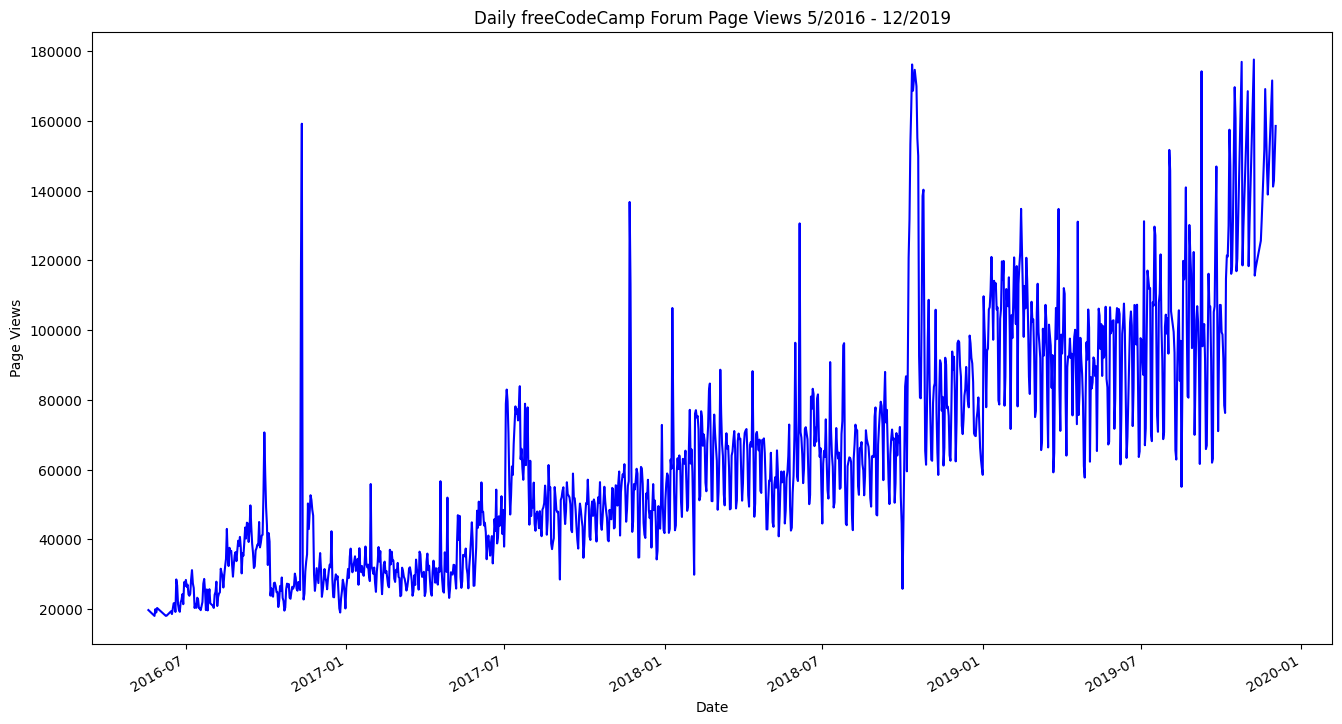

In [20]:
def draw_line_plot():
  dfc = df.copy() #create a new variable with a copy of the original DataFrame
  line_plot = dfc.plot(figsize=(16, 9), color='b', legend=False)
  plt.title('Daily freeCodeCamp Forum Page Views 5/2016 - 12/2019')
  plt.xlabel('Date')
  plt.ylabel('Page Views')

  #line_plot = line_plot.figure
  #line_plot.savefig('visits_forum_line_plot.png')
  return line_plot

draw_line_plot()

**Create a draw_bar_plot function that draws a bar chart. It should show average daily page views for each month grouped by year. The legend should show month labels and have a title of Months. On the chart, the label on the x axis should be Years and the label on the y axis should be Average Page Views.**

<Axes: xlabel='Years', ylabel='Average Page Views'>

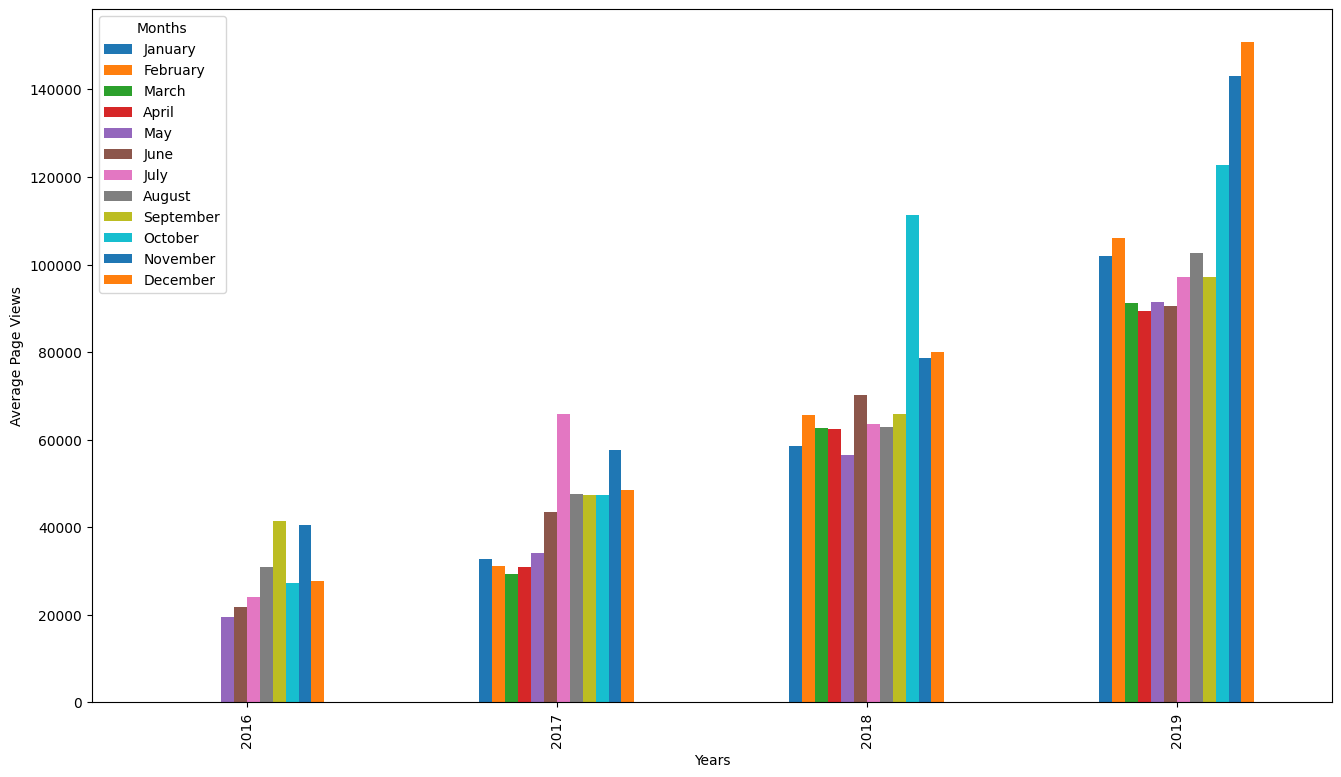

In [21]:
def draw_bar_plot():
  dfc = df.copy() #create a new variable with a copy of the original DataFrame

  #modify the copy of the dataframe before create the monthly bar plot
  dfc.reset_index(inplace=True) #reset the indexes
  dfc['year'] = pd.DatetimeIndex(dfc['date']).year #get the years from the column date and assign to a column named 'year'
  dfc['month'] = pd.DatetimeIndex(dfc['date']).month_name() #get month names from the column date and assign to a column named 'month'

  #regroup and organizing the dataframe in a new variable
  dfc_grouped = dfc.groupby(['year', 'month'])['value'].mean() #get the mean value of visits per month
  dfc_grouped = dfc_grouped.unstack(level='month') #unstack method for handle Series with multi index (year and month)
  #specify the order of months
  month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
  dfc_grouped = dfc_grouped[month_order] #assign the order of months to the variable

  #create a new variable for the bar plot
  fig = dfc_grouped.plot(kind='bar', figsize=(16, 9), legend=True)
  plt.xlabel('Years')
  plt.ylabel('Average Page Views')
  plt.legend(title='Months', loc='upper left')

  #fig = fig.figure
  #fig.savefig('year_months_bar_plot.png')
  return fig

draw_bar_plot()

**Create a draw_box_plot function that uses Seaborn to draw two adjacent box plots. These box plot should show how the values are distributed within a given year or month and how it compares over time. The title of the first chart should be Year-Wise Box Plot (Trend) and the title of the second chart should be Month-Wise Box Plot (Seasonality). Make sure the month labels on bottom start at Jan and the x and y axis are labeled correctly. The boilerplate includes commands to prepare the data.**

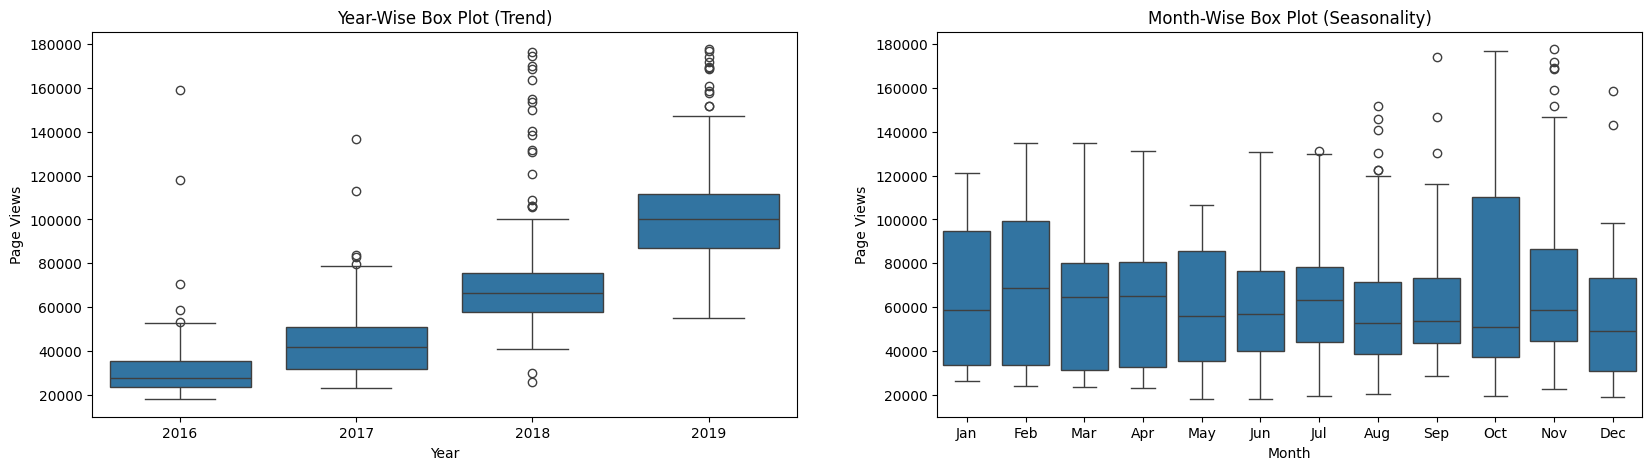

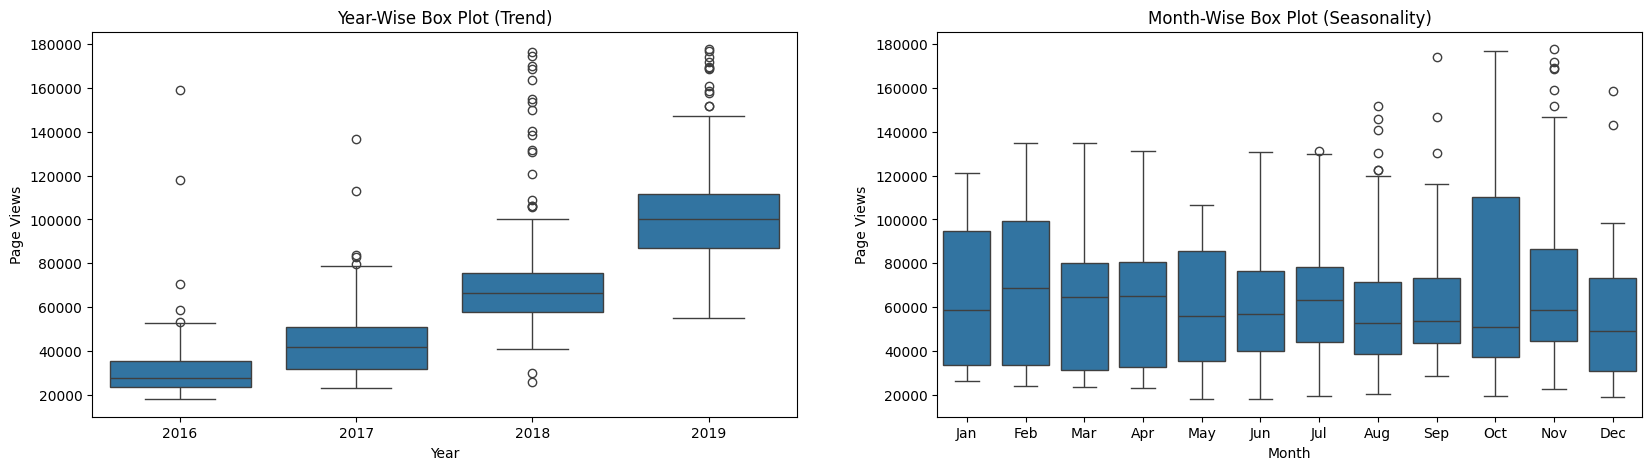

In [22]:
#this function work if the date column is a DateTime object, not a string
#draw_box_plot(df, 'date', 'values')
def draw_box_plot():
  dfc = df.copy() #create a new variable with a copy of the original DataFrame
  dfc.reset_index(inplace=True) #reset the indexes
  dfc['year'] = [d.year for d in dfc.date] #iterate and obtain a list with the years
  dfc['month'] = [d.strftime('%b') for d in dfc.date] #iterate and obtain a list with the abreviation of the months names

  #variable with a list containing the months names abreviated
  mon_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

  #create the form for the final plot, two graphs in one figure
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))

  #ax's variables will contain each boxplot, for year and month respectively
  ax1 = sns.boxplot(x='year', y='value', data=dfc, ax=ax1)
  ax2 = sns.boxplot(x='month', y='value', data=dfc, ax=ax2, order=mon_order) #call the mon_order variable to set the order of months to display

  #set the name labels for the year graph
  ax1.set_title('Year-Wise Box Plot (Trend)')
  ax1.set_xlabel('Year')
  ax1.set_ylabel('Page Views')

  #set the name labels for the month graph
  ax2.set_title('Month-Wise Box Plot (Seasonality)')
  ax2.set_xlabel('Month')
  ax2.set_ylabel('Page Views')

  #plt.tight_layout()
  #plt.show()

  #fig = fig.figure
  #fig.savefig('year_month_box_plot.png')
  return fig

draw_box_plot()

**For each chart, make sure to use a copy of the dataframe**